# 15 -- K=5 PAE with Full VIM (No Filtering), 3 seeds

Runs the K=5 PAE on the full dataset **without** removing VIM-high cells, to characterise all cell populations including VIM-high stromal/mesenchymal cells.

**Configured for:** breast CyTOF dataset (`normalized_not_scaled`, 15 samples, ~1.1M cells)  
**Config:** `configs/breast_pae_withvim_k5.yaml` -- K=5, 3 seeds  
**h5ad:** `data/breast_cytof_withvim_processed.h5ad`  

**Pipeline:** load all cells → clip → balanced per-sample downsample → equal-sample z-score  
(No VIM removal -- VIM-high mesenchymal cells are intentionally retained)

In [1]:
from pathlib import Path
import sys

def _find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'pyproject.toml').exists() and (path / 'src' / 'cytof_archetypes').exists():
            return path
    fallback = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
    if (fallback / 'src' / 'cytof_archetypes').exists():
        return fallback
    raise RuntimeError('Could not locate repository root')

REPO_ROOT = _find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
print('Repo root:', REPO_ROOT)

Repo root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv


## Step 1 -- Prepare Data (VIM Retained)

Merges all `normalized_not_scaled_*.parquet` files (excluding `.2` replicate samples) into `data/breast_cytof_withvim_processed.h5ad`. Skips if file already exists.

- Excludes backbone markers: `H3`, `H4`, `H3.3`
- Clips each marker to `[0, 99.9th percentile]`
- Balanced per-sample downsampling to `TARGET_TOTAL_CELLS // n_samples` each
- Equal-sample z-score normalisation
- **No VIM-high removal**

In [2]:
import re
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# -- Data prep config -----------------------------------------------------
BREAST_DATA_DIR  = Path('/Users/ronguy/Dropbox/CyTOF_Breast/for_guy')
FILE_VARIANT     = 'normalized_not_scaled'
FILE_EXTENSION   = 'parquet'
SAMPLE_ID_REGEX  = r'_([0-9]+(?:\.[0-9]+)?)$'
EXCLUDE_DOT2     = True                   # skip .2 samples (replicates)
EXCLUDED_MARKERS = ['H3', 'H4', 'H3.3']  # backbone markers

# Downsampling -- applied AFTER VIM removal, equal cells per sample
TARGET_TOTAL_CELLS = 150_000
RANDOM_STATE       = 42

# Clipping
CLIP_MARKERS = True
CLIP_UPPER_PERCENTILE = 99.9

# VIM removal -- applied to ALL cells BEFORE downsampling
REMOVE_VIM_HIGH_COMPONENT = False
VIM_MARKER_CANDIDATES     = ['VIM', 'Vimentin']
VIM_MARKER_MATCH_MODE     = 'contains'
VIM_GMM_RANDOM_STATE      = 42
VIM_GMM_MAX_ITER          = 300

# Z-score -- equal-sample weighted, applied AFTER downsampling
APPLY_SAMPLE_WEIGHTED_ZSCORE = True
ZSCORE_WEIGHT_MODE           = 'equal_samples'
ZSCORE_EPS                   = 1e-8

OUTPUT_H5AD      = REPO_ROOT / 'data' / 'breast_cytof_withvim_processed.h5ad'
FORCE_REGENERATE = True
# -------------------------------------------------------------------------


def parse_sample_id(file_path, sample_id_regex):
    stem = file_path.stem
    m = re.search(sample_id_regex, stem)
    if m is not None:
        return m.group(1)
    fallback = re.findall(r'[0-9]+(?:\.[0-9]+)?', stem)
    if fallback:
        return fallback[-1]
    raise ValueError(f'Could not parse sample id from filename: {file_path.name}')


def marker_is_excluded(marker, excluded_markers):
    marker_norm = marker.strip().lower()
    excluded_norm = {m.strip().lower() for m in excluded_markers}
    return marker_norm in excluded_norm


def find_marker_index(marker_names, candidates, mode='contains'):
    names = [str(m) for m in marker_names]
    cand_norm = [c.strip().lower() for c in candidates]
    if mode == 'exact':
        for i, m in enumerate(names):
            if m.strip().lower() in cand_norm:
                return i
    elif mode == 'contains':
        for i, m in enumerate(names):
            m_norm = m.strip().lower()
            if any(c in m_norm for c in cand_norm):
                return i
    else:
        raise ValueError("mode must be 'exact' or 'contains'.")
    raise ValueError(f'Could not find VIM marker. Candidates: {candidates}; markers: {names[:15]} ...')


def remove_vim_high_component(X, sample_ids, marker_names, marker_candidates,
                               match_mode='contains', random_state=42, max_iter=300):
    vim_idx  = find_marker_index(marker_names, marker_candidates, mode=match_mode)
    vim_name = marker_names[vim_idx]
    values   = X[:, vim_idx].reshape(-1, 1)
    gmm = GaussianMixture(
        n_components=2,
        covariance_type='full',
        random_state=random_state,
        n_init=5,
        max_iter=max_iter,
    )
    labels         = gmm.fit_predict(values)
    means          = gmm.means_.ravel()
    high_component = int(np.argmax(means))
    keep_mask      = labels != high_component
    X_out          = X[keep_mask]
    sample_ids_out = sample_ids[keep_mask]
    covs = gmm.covariances_.reshape(2)
    stds = np.sqrt(np.clip(covs, 1e-12, None))
    info = {
        'vim_marker':        vim_name,
        'vim_idx':           int(vim_idx),
        'component_means':   means.tolist(),
        'component_stds':    stds.tolist(),
        'component_weights': gmm.weights_.tolist(),
        'high_component':    int(high_component),
        'removed_cells':     int((~keep_mask).sum()),
        'kept_cells':        int(keep_mask.sum()),
        'vim_values_before': values.ravel().astype(np.float32),
    }
    return X_out, sample_ids_out, keep_mask, info


def balanced_downsample(X, sample_ids, target_total, rng):
    """Downsample each sample to equal cell count, total ~= target_total."""
    unique_samples = np.unique(sample_ids)
    n_samples = len(unique_samples)
    per_sample_target = max(1, target_total // n_samples)
    keep_indices = []
    for sid in unique_samples:
        idx = np.where(sample_ids == sid)[0]
        if len(idx) <= per_sample_target:
            keep_indices.append(idx)
        else:
            chosen = rng.choice(idx, size=per_sample_target, replace=False)
            keep_indices.append(chosen)
    keep_sorted = np.sort(np.concatenate(keep_indices))
    return X[keep_sorted], sample_ids[keep_sorted]


def sample_weighted_zscore(X, sample_ids, eps=1e-8, weight_mode='equal_samples'):
    sample_ids = np.asarray(sample_ids)
    unique_samples, counts = np.unique(sample_ids, return_counts=True)
    if weight_mode == 'by_cells':
        weights = counts.astype(np.float64)
    elif weight_mode == 'equal_samples':
        weights = np.ones_like(counts, dtype=np.float64)
    elif weight_mode == 'inverse_cells':
        weights = 1.0 / np.clip(counts.astype(np.float64), 1.0, None)
    else:
        raise ValueError("weight_mode must be 'by_cells', 'equal_samples', or 'inverse_cells'.")
    weights = weights / float(weights.sum())

    sample_means = [X[sample_ids == s].mean(axis=0) for s in unique_samples]
    sample_means_arr = np.vstack(sample_means)
    center = np.sum(sample_means_arr * weights[:, None], axis=0)

    sample_var = [np.mean((X[sample_ids == s] - center[None, :]) ** 2, axis=0)
                  for s in unique_samples]
    var   = np.sum(np.vstack(sample_var) * weights[:, None], axis=0)
    scale = np.sqrt(np.clip(var, eps, None))

    Xz = (X - center[None, :]) / scale[None, :]
    return Xz.astype(np.float32, copy=False), center.astype(np.float32), scale.astype(np.float32)


if OUTPUT_H5AD.exists() and not FORCE_REGENERATE:
    print(f'h5ad already exists: {OUTPUT_H5AD}')
    print('Set FORCE_REGENERATE = True to rebuild.')
    vim_info = None
    z_center = z_scale = None
else:
    if OUTPUT_H5AD.exists() and FORCE_REGENERATE:
        OUTPUT_H5AD.unlink()
        print(f'Deleted existing h5ad (FORCE_REGENERATE=True).')

    try:
        import anndata as ad
    except ImportError:
        raise ImportError('anndata required: pip install anndata')

    pattern = f'{FILE_VARIANT}_*.{FILE_EXTENSION.lstrip(".")}'  
    files = sorted(BREAST_DATA_DIR.glob(pattern))
    assert files, f'No files matched {pattern!r} in {BREAST_DATA_DIR}'

    def _sort_key(p):
        sid = parse_sample_id(p, SAMPLE_ID_REGEX)
        try:
            return (float(sid), p.name)
        except ValueError:
            return (float('inf'), p.name)

    files = sorted(files, key=_sort_key)
    if EXCLUDE_DOT2:
        kept, excluded = [], []
        for fp in files:
            sid = parse_sample_id(fp, SAMPLE_ID_REGEX)
            (excluded if str(sid).endswith('.2') else kept).append(fp)
        if excluded:
            print(f'Excluded {len(excluded)} .2 replicate files.')
        files = kept

    print(f'Found {len(files)} files after exclusions.')
    print('Step 1/4: Loading all cells...')

    all_tables      = []
    sample_id_lists = []
    common_markers  = None

    for fp in files:
        sid = parse_sample_id(fp, SAMPLE_ID_REGEX)
        df  = pd.read_parquet(fp)

        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        marker_cols_file = [c for c in numeric_cols if not marker_is_excluded(c, EXCLUDED_MARKERS)]
        if not marker_cols_file:
            print(f'  Warning: skipping {fp.name} (no valid marker columns)')
            continue

        if common_markers is None:
            common_markers = list(marker_cols_file)
        else:
            common_set = set(marker_cols_file)
            common_markers = [c for c in common_markers if c in common_set]

        all_tables.append(df[marker_cols_file].copy())
        sample_id_lists.extend([sid] * len(df))
        print(f'  Loaded {fp.name}  ({len(df):,} cells)')

    assert all_tables, 'No data loaded.'
    assert common_markers, 'No common markers found.'

    common_markers = sorted(common_markers, key=lambda x: str(x).lower())
    all_tables = [t[common_markers].reset_index(drop=True) for t in all_tables]
    print(f'Common markers ({len(common_markers)}): {common_markers}')

    X          = pd.concat(all_tables, axis=0, ignore_index=True).to_numpy(dtype=np.float32)
    sample_ids = np.array(sample_id_lists, dtype=object)
    print(f'\nTotal cells loaded: {len(X):,}')

    if CLIP_MARKERS:
        upper = np.percentile(X, CLIP_UPPER_PERCENTILE, axis=0)
        X = np.clip(X, 0.0, upper).astype(np.float32)
        print(f'Applied per-marker clipping to [0, p{CLIP_UPPER_PERCENTILE}].')

    # Step 2: VIM removal on full dataset (before downsampling)
    vim_info = None
    if REMOVE_VIM_HIGH_COMPONENT:
        print('\nStep 2/4: Removing VIM-high component...')
        X, sample_ids, keep_mask, vim_info = remove_vim_high_component(
            X=X,
            sample_ids=sample_ids,
            marker_names=common_markers,
            marker_candidates=VIM_MARKER_CANDIDATES,
            match_mode=VIM_MARKER_MATCH_MODE,
            random_state=VIM_GMM_RANDOM_STATE,
            max_iter=VIM_GMM_MAX_ITER,
        )
        print(
            f"  Marker: '{vim_info['vim_marker']}'  "
            f"means={np.round(vim_info['component_means'], 4)}"
        )
        print(f"  Removed: {vim_info['removed_cells']:,}  |  Kept: {vim_info['kept_cells']:,}")
        _u, _c = np.unique(sample_ids, return_counts=True)
        for s, c in zip(_u, _c):
            print(f'    Sample {s}: {c:,} cells remaining after VIM removal')

    # Step 3: Balanced per-sample downsampling
    print(f'\nStep 3/4: Balanced downsampling -> {TARGET_TOTAL_CELLS:,} cells ({TARGET_TOTAL_CELLS // len(np.unique(sample_ids))} per sample)...')
    rng = np.random.default_rng(RANDOM_STATE)
    X, sample_ids = balanced_downsample(X, sample_ids, TARGET_TOTAL_CELLS, rng)
    _u, _c = np.unique(sample_ids, return_counts=True)
    print(f'  Total after downsampling: {len(X):,}')
    for s, c in zip(_u, _c):
        print(f'    Sample {s}: {c:,} cells')

    # Step 4: Equal-sample z-score
    z_center = z_scale = None
    if APPLY_SAMPLE_WEIGHTED_ZSCORE:
        print(f'\nStep 4/4: Equal-sample z-score (mode={ZSCORE_WEIGHT_MODE})...')
        X, z_center, z_scale = sample_weighted_zscore(
            X=X, sample_ids=sample_ids, eps=ZSCORE_EPS, weight_mode=ZSCORE_WEIGHT_MODE,
        )

    n_cells = len(X)
    obs = pd.DataFrame({
        'cell_id':   [f'cell_{i:07d}' for i in range(n_cells)],
        'sample_id': sample_ids,
    })
    obs.index = obs['cell_id'].values

    adata = ad.AnnData(X=X, obs=obs, var=pd.DataFrame(index=common_markers))
    OUTPUT_H5AD.parent.mkdir(parents=True, exist_ok=True)
    adata.write_h5ad(OUTPUT_H5AD)
    print(f'\nSaved: {OUTPUT_H5AD}  ({adata.shape[0]:,} cells x {adata.shape[1]} markers)')


Excluded 2 .2 replicate files.
Found 15 files after exclusions.
Step 1/4: Loading all cells...
  Loaded normalized_not_scaled_4.parquet  (334,702 cells)
  Loaded normalized_not_scaled_4.1.parquet  (99,453 cells)
  Loaded normalized_not_scaled_5.parquet  (63,184 cells)
  Loaded normalized_not_scaled_7.parquet  (57,094 cells)
  Loaded normalized_not_scaled_7.1.parquet  (36,985 cells)
  Loaded normalized_not_scaled_8.parquet  (108,541 cells)
  Loaded normalized_not_scaled_8.1.parquet  (105,648 cells)
  Loaded normalized_not_scaled_11.parquet  (33,060 cells)
  Loaded normalized_not_scaled_13.parquet  (21,668 cells)
  Loaded normalized_not_scaled_14.parquet  (49,467 cells)
  Loaded normalized_not_scaled_15.parquet  (35,081 cells)
  Loaded normalized_not_scaled_17.parquet  (32,604 cells)
  Loaded normalized_not_scaled_18.parquet  (39,114 cells)
  Loaded normalized_not_scaled_19.parquet  (55,842 cells)
  Loaded normalized_not_scaled_20.parquet  (59,345 cells)
Common markers (31): ['aSMA', 'BM

In [3]:
import anndata as ad

adata=ad.read_h5ad(OUTPUT_H5AD)
adata.obs.groupby('sample_id').size()

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_18579/1702982743.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('sample_id').size()


sample_id
4      10000
4.1    10000
5      10000
7      10000
7.1    10000
8      10000
8.1    10000
11     10000
13     10000
14     10000
15     10000
17     10000
18     10000
19     10000
20     10000
dtype: int64

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

if vim_info is None:
    print('No VIM removal was performed — skipping diagnostic plot.')
else:
    x_vals  = np.asarray(vim_info['vim_values_before'], dtype=float)
    means   = np.asarray(vim_info['component_means'],   dtype=float)
    stds    = np.asarray(vim_info['component_stds'],    dtype=float)
    weights = np.asarray(vim_info['component_weights'], dtype=float)
    high_idx = int(vim_info['high_component'])

    x_min, x_max = float(np.min(x_vals)), float(np.max(x_vals))
    x_grid = np.linspace(x_min, x_max, 600)

    comp_pdf = []
    for m, s, w in zip(means, stds, weights):
        comp_pdf.append(w * norm.pdf(x_grid, loc=m, scale=max(s, 1e-6)))
    comp_pdf = np.asarray(comp_pdf)
    mix_pdf  = np.sum(comp_pdf, axis=0)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.hist(x_vals, bins=120, density=True, alpha=0.35, color='gray', label='Vimentin values')
    colors = ['tab:blue', 'tab:red']
    for ci in range(comp_pdf.shape[0]):
        tag = 'removed high component' if ci == high_idx else 'kept low component'
        ax.plot(x_grid, comp_pdf[ci], color=colors[ci % len(colors)], lw=2.0,
                label=f'component {ci} ({tag})')
        ax.axvline(means[ci], color=colors[ci % len(colors)], lw=1.2, ls='--')
    ax.plot(x_grid, mix_pdf, color='black', lw=2.2, label='mixture pdf')
    ax.set_title(f"Vimentin 2-component GMM diagnostic: {vim_info['vim_marker']}")
    ax.set_xlabel(vim_info['vim_marker'])
    ax.set_ylabel('Density')
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    print(f"VIM marker : {vim_info['vim_marker']}  (col {vim_info['vim_idx']})")
    print(f"Means      : {np.round(vim_info['component_means'], 4)}")
    print(f"Stds       : {np.round(vim_info['component_stds'], 4)}")
    print(f"Weights    : {np.round(vim_info['component_weights'], 4)}")
    total = vim_info['removed_cells'] + vim_info['kept_cells']
    print(f"Removed    : {vim_info['removed_cells']:,} / {total:,} cells "
          f"({100*vim_info['removed_cells']/total:.1f}%)")


No VIM removal was performed — skipping diagnostic plot.


## Step 2 — Run the K Sweep

The cell below runs the sweep directly. Set `RUN_SWEEP = False` to skip if you've already run it.

Alternatively, run from terminal:
```bash
python scripts/run_experiment_suite.py --config configs/breast_pae_k_sweep.yaml
```

In [5]:
adata.obs.groupby('sample_id').size()

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_18579/59469272.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('sample_id').size()


sample_id
4      10000
4.1    10000
5      10000
7      10000
7.1    10000
8      10000
8.1    10000
11     10000
13     10000
14     10000
15     10000
17     10000
18     10000
19     10000
20     10000
dtype: int64

In [6]:
import os
import time
from cytof_archetypes.experiments import load_suite_config, run_experiment_suite

CONFIG_PATH = REPO_ROOT / 'configs' / 'breast_pae_withvim_k5.yaml'
assert CONFIG_PATH.exists(), f'Missing config: {CONFIG_PATH}'

RUN_SWEEP = True   # set to False to skip and go straight to analysis

cfg = load_suite_config(CONFIG_PATH)
_env = os.environ.get('CYTOF_SUITE_OUTPUT_DIR')
if _env:
    cfg['output_dir'] = _env

# Enable live loss plot
cfg['show_progress'] = True
cfg['show_run_logs'] = True
cfg['show_training_progress'] = True
pae_cfg = cfg.setdefault('methods', {}).setdefault('probabilistic_archetypal_ae', {})
pae_cfg['live_loss_plot'] = False  # tqdm status bar shows loss instead
pae_cfg['show_training_progress'] = True

print('Config:', CONFIG_PATH)
print('Output dir:', cfg['output_dir'])
print('K sweep:', cfg.get('sweeps', {}).get('k_values', []))
print('Seeds:', cfg.get('seeds', []))
print('Downsample factor:', cfg.get('dataset', {}).get('downsample_factor', 'none'))

if RUN_SWEEP:
    t0 = time.time()
    out_dir = run_experiment_suite(cfg)
    print(f'Sweep completed in {(time.time()-t0)/60:.1f} min  |  output: {out_dir}')
else:
    print('Sweep skipped (RUN_SWEEP=False). Using existing outputs.')

Config: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/configs/breast_pae_withvim_k5.yaml
Output dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/breast_pae_withvim_k5
K sweep: [5]
Seeds: [42, 123, 456]
Downsample factor: none


Suite phases:   0%|          | 0/12 [00:00<?, ?phase/s]

[suite-phase] 1/12: prepare_data
[suite-phase] 2/12: run_core_benchmark (all methods × dims × seeds)


MPS/GPU benchmark runs:   0%|          | 0/3 [00:00<?, ?run/s]

[core-stage] running 3 MPS/GPU+serial jobs
[core-run 1/3] START method=probabilistic_archetypal_ae dim=5 seed=42 device=mps


...

[core-run 3/3] DONE  method=probabilistic_archetypal_ae dim=5 seed=456 val_mse=0.523069 test_mse=0.527954 elapsed=20.1s
[accel-stage 3/3] method=probabilistic_archetypal_ae dim=5 seed=456
[suite-phase] 3/12: run_fit_vs_complexity
[suite-phase] 4/12: run_deconvolution_quality
[suite-phase] 5/12: run_deterministic_vs_probabilistic
[umap] fitting on all 22,500 points ...
UMAP(min_dist=0.2, n_jobs=1, n_neighbors=20, random_state=0, verbose=True)
Tue Apr  7 20:34:05 2026 Construct fuzzy simplicial set
Tue Apr  7 20:34:05 2026 Finding Nearest Neighbors
Tue Apr  7 20:34:05 2026 Building RP forest with 13 trees


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Apr  7 20:34:07 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	Stopping threshold met -- exiting after 2 iterations
Tue Apr  7 20:34:11 2026 Finished Nearest Neighbor Search
Tue Apr  7 20:34:12 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Apr  7 20:34:20 2026 Finished embedding
[umap] transforming 22,500 points in 1 chunk(s) of 100,000 ...
[umap]   chunk 1/1: rows 0–22,500
[umap] done. Output shape: (22500, 2)
[suite-phase] 6/12: run_k_selection
[suite-phase] 7/12: run_component_biology
[suite-phase] 8/12: run_rare_population_preservation
[suite-phase] 9/12: run_secondary_dataset_validation
[suite-phase] 10/12: run_auxiliary_representation_models
[suite-phase] 11/12: run_interpretability_tradeoff
[suite-phase] 12/12: generate_benchmark_notebooks -> /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/notebooks/experiment_suite
Sweep completed in 1.6 min  |  output: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/Pr

In [7]:
import os

# ── USER CONFIG ───────────────────────────────────────────────────────────────
OUTPUT_DIR    = REPO_ROOT / 'outputs' / 'breast_pae_novim_k_sweep'
METHOD        = 'probabilistic_archetypal_ae'
K_VALUES      = None    # None = auto-discover from dim_* subdirectories
VAR_THRESH    = 1e5     # mean archetype variance above this = dead
ASSIGN_THRESH = 0.25    # max_weight threshold for 'assigned' cell
# ─────────────────────────────────────────────────────────────────────────────

_env = os.environ.get('CYTOF_SUITE_OUTPUT_DIR')
if _env:
    OUTPUT_DIR    = REPO_ROOT / 'outputs' / 'breast_pae_novim_k_sweep'

RUNS_DIR = OUTPUT_DIR / 'runs' / METHOD
if not RUNS_DIR.exists():
    print(f'Runs directory not found: {RUNS_DIR}')
    print('Run the sweep first (Step 2 above).')
else:
    if K_VALUES is None:
        K_VALUES = sorted([
            int(p.name.split('_')[1])
            for p in RUNS_DIR.iterdir()
            if p.is_dir() and p.name.startswith('dim_') and p.name.split('_')[1].isdigit()
        ])
    print(f'Output dir:  {OUTPUT_DIR}')
    print(f'K values:    {K_VALUES}')

Output dir:  /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/breast_pae_novim_k_sweep
K values:    [4, 5, 6, 7]


In [8]:
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment
from itertools import combinations


def _load_run(k, seed):
    # find the actual directory regardless of zero-padding (dim_4 vs dim_04)
    dim_matches = [p for p in RUNS_DIR.iterdir()
                   if p.is_dir() and p.name.startswith('dim_')
                   and p.name.split('_')[-1].isdigit()
                   and int(p.name.split('_')[-1]) == k]
    if not dim_matches: return None
    run_dir = dim_matches[0] / f'seed_{seed}'
    required = [run_dir/'component_means.csv', run_dir/'component_vars.csv', run_dir/'training_history.csv']
    weight_paths = [run_dir/'val'/'weights.csv', run_dir/'test'/'weights.csv', run_dir/'train'/'weights.csv']
    if not all(p.exists() for p in required): return None
    if not any(p.exists() for p in weight_paths): return None
    means = pd.read_csv(run_dir/'component_means.csv', index_col=0)
    cvars = pd.read_csv(run_dir/'component_vars.csv', index_col=0)
    hist  = pd.read_csv(run_dir/'training_history.csv')
    wframes = []
    for p in weight_paths:
        if p.exists():
            df = pd.read_csv(p, index_col=0)
            wframes.append(df[[c for c in df.columns if c.startswith('w_')]])
    W = pd.concat(wframes).values.astype('float32')
    return dict(k=k, seed=seed, means=means, cvars=cvars, hist=hist, W=W)


def _compute_metrics(run):
    k, means, cvars, hist, W = run['k'], run['means'], run['cvars'], run['hist'], run['W']
    best_val_loss = hist['val_loss'].min()
    n_epochs      = len(hist)
    mean_var      = cvars.mean(axis=1).values
    n_active      = int((mean_var < VAR_THRESH).sum())
    W_safe        = np.clip(W, 1e-9, 1.0)
    entropy       = -(W_safe * np.log(W_safe)).sum(axis=1)
    effective_k   = float(np.exp(entropy.mean()))
    M             = means.values
    diffs         = [np.linalg.norm(M[i]-M[j]) for i,j in combinations(range(k),2)] if k>1 else [0.]
    return dict(k=k, seed=run['seed'],
                best_val_loss=best_val_loss, n_epochs=n_epochs,
                n_active=n_active, active_frac=n_active/k,
                effective_k=effective_k, effective_k_frac=effective_k/k,
                diversity=float(np.mean(diffs)),
                assign_frac=float((W.max(axis=1)>=ASSIGN_THRESH).mean()),
                mean_entropy=entropy.mean())


def _cross_seed_stability(runs_k):
    if len(runs_k) < 2: return float('nan')
    sims = []
    for r1, r2 in combinations(runs_k, 2):
        M1 = r1['means'].values; M2 = r2['means'].values
        n1 = M1 / (np.linalg.norm(M1, axis=1, keepdims=True)+1e-9)
        n2 = M2 / (np.linalg.norm(M2, axis=1, keepdims=True)+1e-9)
        C  = n1 @ n2.T
        ri, ci = linear_sum_assignment(1-C)
        sims.append(float(C[ri,ci].mean()))
    return float(np.mean(sims))


all_runs, all_metrics = {}, []
for k in K_VALUES:
    dim_matches = [p for p in RUNS_DIR.iterdir()
                   if p.is_dir() and p.name.startswith('dim_')
                   and p.name.split('_')[-1].isdigit()
                   and int(p.name.split('_')[-1]) == k]
    if not dim_matches: print(f'  K={k}: not found, skipping'); continue
    dim_dir = dim_matches[0]
    runs_k = []
    for sd in sorted(p for p in dim_dir.iterdir() if p.is_dir() and p.name.startswith('seed_')):
        run = _load_run(k, int(sd.name.split('_')[1]))
        if run is None: print(f'  K={k} {sd.name}: incomplete'); continue
        runs_k.append(run); all_metrics.append(_compute_metrics(run))
    all_runs[k] = runs_k
    print(f'  K={k}: {len(runs_k)} seed(s) loaded')

metrics_df = pd.DataFrame(all_metrics)
print(f'\nTotal runs: {len(metrics_df)}')
display(metrics_df.round(4))

  K=4: 3 seed(s) loaded
  K=5: 3 seed(s) loaded
  K=6: 3 seed(s) loaded
  K=7: 3 seed(s) loaded

Total runs: 12


,k,seed,best_val_loss,n_epochs,n_active,active_frac,effective_k,effective_k_frac,diversity,assign_frac,mean_entropy
0,4,123,29.6534,456,4,1.0,3.1517,0.7879,14.4925,1.0000,1.1480
1,4,42,29.6505,457,4,1.0,3.1762,0.7940,14.3648,1.0000,1.1557
2,4,456,29.5921,508,4,1.0,3.2070,0.8017,14.7166,1.0000,1.1653
3,5,123,26.5361,579,5,1.0,3.9729,0.7946,17.3728,0.9927,1.3795
4,5,42,26.7711,524,5,1.0,3.9157,0.7831,16.5579,0.9942,1.3650
5,5,456,26.5591,659,5,1.0,3.9433,0.7887,18.7800,0.9951,1.3720
6,6,123,24.2375,824,6,1.0,4.9924,0.8321,21.8289,0.8694,1.6079
7,6,42,24.2784,822,6,1.0,4.8932,0.8155,20.9598,0.9150,1.5878
8,6,456,25.1360,597,6,1.0,4.6762,0.7794,18.7586,0.9541,1.5425
9,7,123,22.4000,746,7,1.0,5.5040,0.7863,20.2695,0.7122,1.7055


In [9]:
stability    = {k: _cross_seed_stability(runs) for k, runs in all_runs.items()}
stability_df = pd.DataFrame([{'k':k,'cross_seed_stability':v} for k,v in stability.items()])

agg = metrics_df.groupby('k').agg(
    best_val_loss_mean=('best_val_loss','mean'), best_val_loss_std=('best_val_loss','std'),
    active_frac_mean=('active_frac','mean'), effective_k_mean=('effective_k','mean'),
    effective_k_frac_mean=('effective_k_frac','mean'), diversity_mean=('diversity','mean'),
    assign_frac_mean=('assign_frac','mean'), n_seeds=('seed','count'),
).reset_index().merge(stability_df, on='k', how='left')

print('Per-K summary:')
display(agg.round(4))

Per-K summary:


,k,best_val_loss_mean,best_val_loss_std,active_frac_mean,effective_k_mean,effective_k_frac_mean,diversity_mean,assign_frac_mean,n_seeds,cross_seed_stability
0,4,29.6320,0.0346,1.0,3.1783,0.7946,14.5246,1.0000,3,0.9940
1,5,26.6221,0.1295,1.0,3.9440,0.7888,17.5702,0.9940,3,0.8358
2,6,24.5506,0.5073,1.0,4.8539,0.8090,20.5158,0.9128,3,0.7907
3,7,23.5354,1.5167,1.0,5.1436,0.7348,18.8274,0.8235,3,0.7146


## Diagnostic Plots

| Panel | What to look for |
|---|---|
| Val loss | Elbow — marginal gain flattens |
| Active fraction | Should stay 1.0; drop = collapse |
| Effective K | Should track K; plateau = redundant archetypes |
| Diversity | Drop = new archetypes become near-duplicates |
| Cross-seed stability | High = robust; low = different random basins |
| Assignment concentration | Fraction of cells with a dominant archetype |

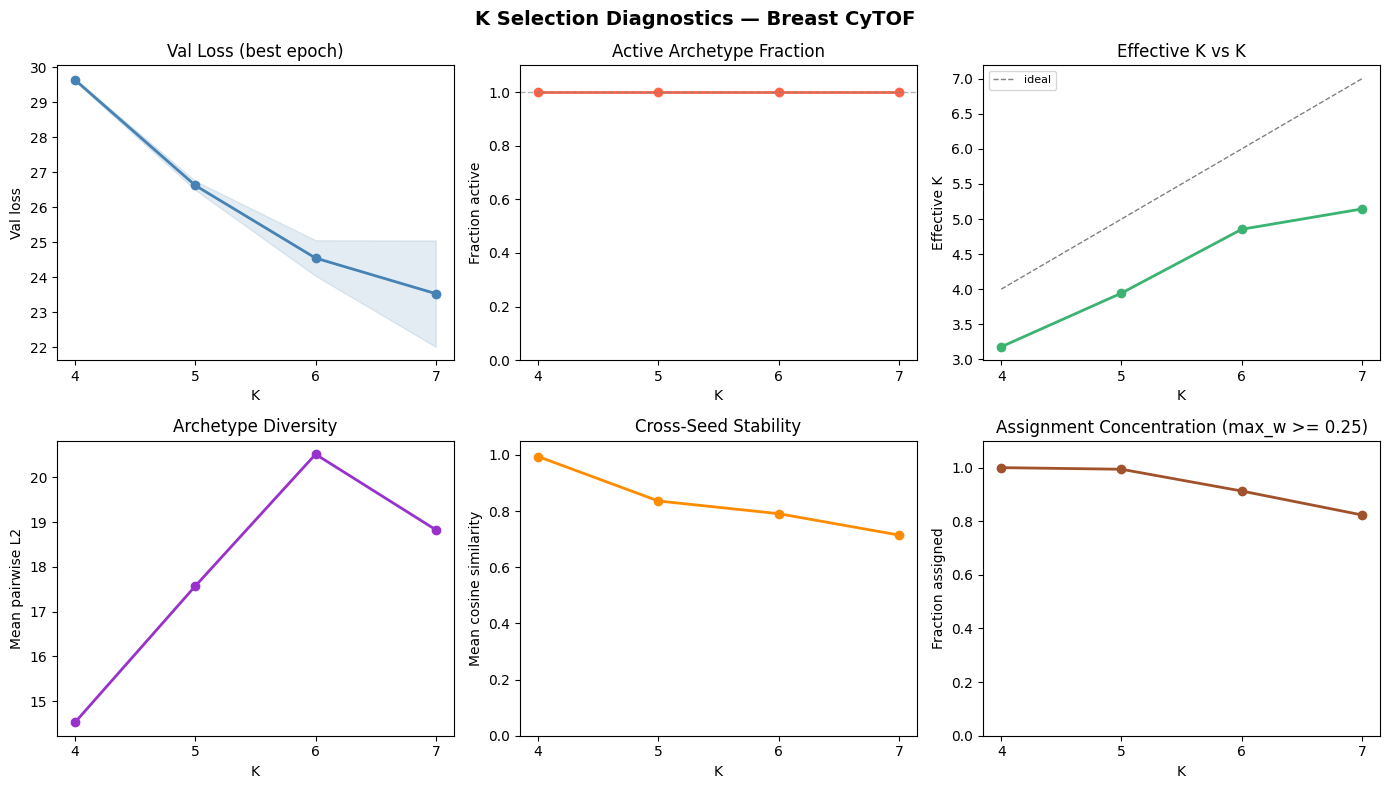

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ks  = agg['k'].values
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('K Selection Diagnostics — Breast CyTOF', fontsize=14, fontweight='bold')

def _plot(ax, col, col_std=None, color='steelblue', ylabel='', title=''):
    y = agg[col].values
    ax.plot(ks, y, 'o-', color=color, linewidth=2, markersize=6)
    if col_std and col_std in agg.columns:
        e = agg[col_std].fillna(0).values
        ax.fill_between(ks, y-e, y+e, color=color, alpha=0.15)
    ax.set_title(title); ax.set_xlabel('K'); ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

_plot(axes[0,0],'best_val_loss_mean','best_val_loss_std','steelblue','Val loss','Val Loss (best epoch)')
_plot(axes[0,1],'active_frac_mean',color='tomato',ylabel='Fraction active',title='Active Archetype Fraction')
axes[0,1].axhline(1.0,color='gray',linestyle='--',linewidth=1,alpha=0.6); axes[0,1].set_ylim(0,1.1)
axes[0,2].plot(ks,ks,'--',color='gray',linewidth=1,label='ideal')
_plot(axes[0,2],'effective_k_mean',color='mediumseagreen',ylabel='Effective K',title='Effective K vs K')
axes[0,2].legend(fontsize=8)
_plot(axes[1,0],'diversity_mean',color='darkorchid',ylabel='Mean pairwise L2',title='Archetype Diversity')
ax=axes[1,1]
if agg['cross_seed_stability'].notna().any():
    ax.plot(ks,agg['cross_seed_stability'].values,'o-',color='darkorange',linewidth=2,markersize=6)
    ax.set_ylim(0,1.05); ax.set_ylabel('Mean cosine similarity')
else:
    ax.text(0.5,0.5,'Only 1 seed per K\n(add more seeds for\nstability estimate)',
            ha='center',va='center',transform=ax.transAxes,fontsize=10,color='gray')
ax.set_title('Cross-Seed Stability'); ax.set_xlabel('K')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
_plot(axes[1,2],'assign_frac_mean',color='sienna',ylabel='Fraction assigned',
      title=f'Assignment Concentration (max_w >= {ASSIGN_THRESH})')
axes[1,2].set_ylim(0,1.1)
fig.tight_layout(); plt.show()

## Automated Recommendation

In [11]:
import warnings
import numpy as np

rec = agg.copy().sort_values('k').reset_index(drop=True)

# ── 1. Marginal loss improvement (elbow-based) ────────────────────────────────
# Instead of rewarding raw loss (monotonically improves with K), reward the
# *marginal gain* of each extra archetype. Score decays toward 0 as the curve
# flattens.  K values past the elbow get near-zero loss score.
losses = rec['best_val_loss_mean'].values.astype(float)
ks     = rec['k'].values.astype(float)

# Marginal improvement per unit K: -(Δloss / Δk), normalised to [0,1]
if len(losses) > 1:
    # Forward differences, pad last entry with 0
    dloss = -np.diff(losses, prepend=losses[0])   # positive = improvement
    dk    = np.diff(ks,     prepend=ks[0])
    dk[dk == 0] = 1
    marginal = np.maximum(dloss / dk, 0)
    marginal_norm = marginal / (marginal.max() + 1e-12)
else:
    marginal_norm = np.ones(len(losses))

rec['score_loss'] = marginal_norm  # high only where adding archetypes still helps

# ── 2. Absolute active archetype count (normalised) ──────────────────────────
# active_frac penalises large K too harshly by proportion.
# Instead reward the *absolute number* of active archetypes; normalise by max.
n_active = rec['active_frac_mean'] * rec['k']   # absolute count
rec['score_active'] = (n_active / (n_active.max() + 1e-12)).clip(0, 1)

# ── 3. Effective K fraction (unchanged) ──────────────────────────────────────
rec['score_eff_k'] = rec['effective_k_frac_mean'].clip(0, 1)

# ── 4. Cross-seed stability (unchanged) ──────────────────────────────────────
rec['score_stability'] = rec['cross_seed_stability'].fillna(0.5).clip(0, 1)

# ── 5. Dead-archetype multiplicative penalty ─────────────────────────────────
# Hard-penalise any K where more than 30% of archetypes are dead.
DEAD_FRAC_LIMIT = 0.30
dead_penalty = np.where(rec['active_frac_mean'] < (1 - DEAD_FRAC_LIMIT),
                        rec['active_frac_mean'] / (1 - DEAD_FRAC_LIMIT),
                        1.0)

# ── 6. Composite score ───────────────────────────────────────────────────────
rec['composite_score'] = (
    (0.30 * rec['score_loss']
   + 0.35 * rec['score_active']
   + 0.25 * rec['score_eff_k']
   + 0.10 * rec['score_stability'])
   * dead_penalty
)

display(rec[['k', 'best_val_loss_mean', 'active_frac_mean', 'effective_k_frac_mean',
             'cross_seed_stability', 'score_loss', 'score_active',
             'composite_score']].sort_values('composite_score', ascending=False).round(4))

best_k = int(rec.loc[rec['composite_score'].idxmax(), 'k'])
print(f'\n>>> Recommended K: {best_k} <<<')

br = rec[rec['k'] == best_k].iloc[0]
n_dead = round((1 - br['active_frac_mean']) * best_k)
if n_dead > 0:
    warnings.warn(f'K={best_k} has ~{n_dead} dead archetype(s) ({1-br["active_frac_mean"]:.0%}).')
if br['effective_k_frac_mean'] < 0.5:
    warnings.warn(f'K={best_k} effective utilisation low ({br["effective_k_frac_mean"]:.1%}).')


,k,best_val_loss_mean,active_frac_mean,effective_k_frac_mean,cross_seed_stability,score_loss,score_active,composite_score
1,5,26.6221,1.0,0.7888,0.8358,1.0000,0.7143,0.8308
2,6,24.5506,1.0,0.8090,0.7907,0.6882,0.8571,0.7878
3,7,23.5354,1.0,0.7348,0.7146,0.3373,1.0000,0.7064
0,4,29.6320,1.0,0.7946,0.9940,0.0000,0.5714,0.4980



>>> Recommended K: 5 <<<


## Per-Archetype Inspection — Recommended K

For the breast dataset, archetypes reflect cell states (luminal/basal subtypes,
mesenchymal/EMT, immune, cycling) rather than named cell types.

In [12]:
best_runs = all_runs.get(best_k, [])
if not best_runs:
    print(f'No runs for K={best_k}')
else:
    r = best_runs[0]
    means, mean_vars = r['means'], r['cvars'].mean(axis=1)
    print(f'K={best_k}, seed={r["seed"]} — archetype profiles (z-score means)\n')
    print(f'{"Arch":<6} {"MeanVar":>10}  {"Status":<8}  Top 4 (+)  |  Bottom 2 (-)')
    print('-'*100)
    for comp in means.index:
        idx  = int(comp.split('_')[1])
        row  = means.loc[comp]
        mvar = mean_vars[comp]
        top4 = row.nlargest(4); bot2 = row.nsmallest(2)
        print(f'A{idx:02d}    {mvar:10.2f}  {"ACTIVE" if mvar<VAR_THRESH else "DEAD":<8}  '
              f'{", ".join(f"{m}={v:+.2f}" for m,v in top4.items()):<55}  '
              f'{", ".join(f"{m}={v:+.2f}" for m,v in bot2.items())}')

K=5, seed=123 — archetype profiles (z-score means)

Arch      MeanVar  Status    Top 4 (+)  |  Bottom 2 (-)
----------------------------------------------------------------------------------------------------
A00          2.23  ACTIVE    H3S28p=+3.54, H3K36me3=+3.41, H3K64ac=+3.11, CD24=+3.09  panKeratin=-2.38, EZH2=-2.24
A01          0.31  ACTIVE    K8-18=+3.90, panKeratin=+3.28, H4K20me3=+2.32, ER=+1.48  H3K64ac=-2.26, H3K4me3=-2.19
A02          5.38  ACTIVE    aSMA=+5.79, K5=+4.23, H3K9me2=+1.99, BMI-1=+0.89         K8-18=-3.97, H4K20me3=-2.24
A03          1.04  ACTIVE    EZH2=+2.38, H3K27me2=+0.88, Ki67=+0.80, EpCam=+0.71      aSMA=-4.46, H3K36me3=-3.55
A04          6.80  ACTIVE    H3K27me2=+4.42, H3K4me3=+3.81, H3K36me2=+3.78, H4K16ac=+3.58  CD24=-1.95, EpCam=-1.16


## Archetype Mean Heatmap — Recommended K

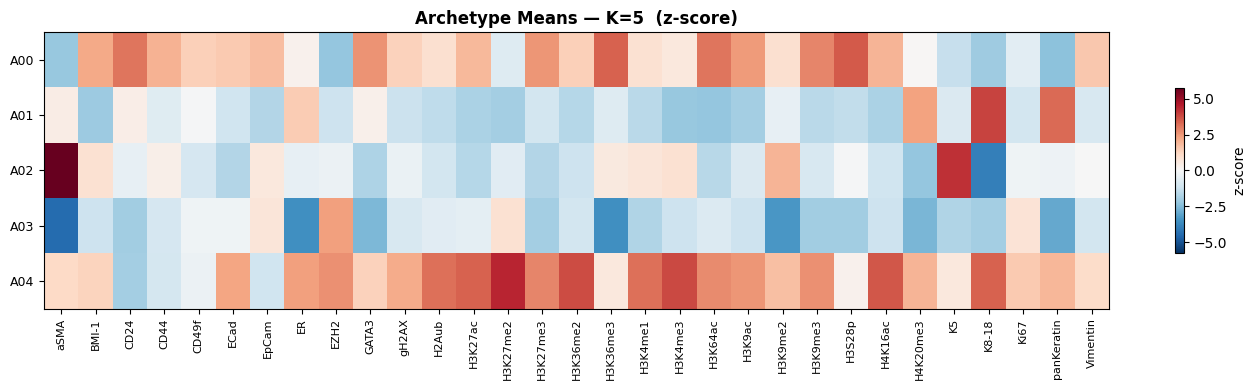

In [13]:
if best_runs:
    r = best_runs[0]
    means = r['means'].copy()
    means.index = [f'A{int(c.split("_")[1]):02d}' for c in means.index]
    vabs = max(abs(means.values.min()), abs(means.values.max()))
    fig, ax = plt.subplots(figsize=(max(10, len(means.columns)*0.45), max(4, best_k*0.5)))
    im = ax.imshow(means.values, aspect='auto', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
    ax.set_xticks(range(len(means.columns)))
    ax.set_xticklabels(means.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(best_k)); ax.set_yticklabels(means.index, fontsize=9)
    ax.set_title(f'Archetype Means — K={best_k}  (z-score)', fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.6, label='z-score')
    fig.tight_layout(); plt.show()